<a href="https://colab.research.google.com/github/ntx-lab/clifford-distribution/blob/main/random_clifford_n_pauli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import stim
import random
from collections import Counter

string_length = 16  # Length of each Pauli string
# num_random_input_pauli_strings now represents N (number of initial random Pauli strings)
num_random_input_pauli_strings = 1000
# num_conjugations_per_pauli now represents M (number of unique random Cliffords to generate)
num_conjugations_per_pauli = 300

all_weights = []

# Function to generate a random Pauli string
def generate_random_pauli_string(length):
    return stim.PauliString.random(length)

# Generate all N initial random Pauli strings once
initial_pauli_strings = [generate_random_pauli_string(string_length) for _ in range(num_random_input_pauli_strings)]

print(f"Generating {num_random_input_pauli_strings} initial random Pauli strings.")
print(f"Applying {num_conjugations_per_pauli} unique random Clifford conjugations. Each Clifford will be applied to all {num_random_input_pauli_strings} initial Pauli strings.")

# Iterate through M unique random Cliffords
for _ in range(num_conjugations_per_pauli):
    # Generate a single random Clifford for this iteration
    c = stim.Tableau.random(string_length)

    # Apply this SAME Clifford to all N initial Pauli strings
    for input_p in initial_pauli_strings:
        out = input_p.after(c, targets=range(string_length))
        weight = out.weight
        all_weights.append(weight)

print(f"Weight distribution after applying {num_conjugations_per_pauli} unique random Cliffords to {num_random_input_pauli_strings} initial Pauli strings each:")
print(Counter(all_weights))

Generating 1000 initial random Pauli strings.
Applying 300 unique random Clifford conjugations. Each Clifford will be applied to all 1000 initial Pauli strings.
Weight distribution after applying 300 unique random Cliffords to 1000 initial Pauli strings each:
Counter({12: 67701, 13: 62308, 11: 53873, 14: 40103, 10: 32845, 15: 16127, 9: 15759, 8: 5981, 16: 3009, 7: 1771, 6: 431, 5: 81, 4: 11})


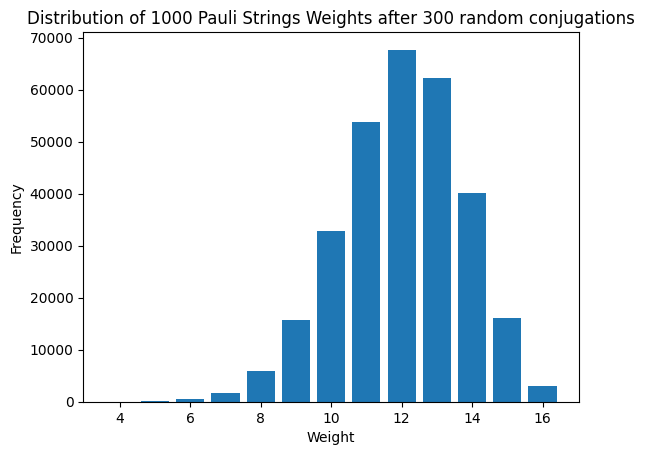

In [11]:
import matplotlib.pyplot as plt

# Ensure all_weights exists from the previous cell execution
if 'all_weights' in locals():
    plt.hist(all_weights, bins=range(min(all_weights), max(all_weights) + 2), align='left', rwidth=0.8)
    plt.xlabel("Weight")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {num_random_input_pauli_strings} Pauli Strings Weights after {num_conjugations_per_pauli} random conjugations")
    plt.show()
else:
    print("Error: 'all_weights' not found. Please run the previous cell first.")